In [1]:
import sys
import os
sys.path.append("/home/karlandersson/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/MasterThesisProject/scripts/heatpipe


In [2]:
import json
import matplotlib.pyplot as plt

from utils.heatpipe_utils import generate_cfgs_seq, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

In [3]:
with open("../../data/reactor_data.json", "r") as f:
    data_guoju = json.load(f)
    data = data_guoju["HeatPipe"]

In [4]:
ncfgs = 1
Qs = [17.316e3 for i in range(ncfgs)]
Ns = [[20, 40] for i in range(len(Qs))]
cfgs = generate_cfgs_seq(data, Ns, Qs)

heatpipes = [Heatpipe(cfg) for cfg in cfgs]

Mesh warning: N_R changed from 20 to 15
Mesh warning: N_Z changed from 40 to 32


In [5]:
solver = Solver(heatpipes)
solver.fsolve()

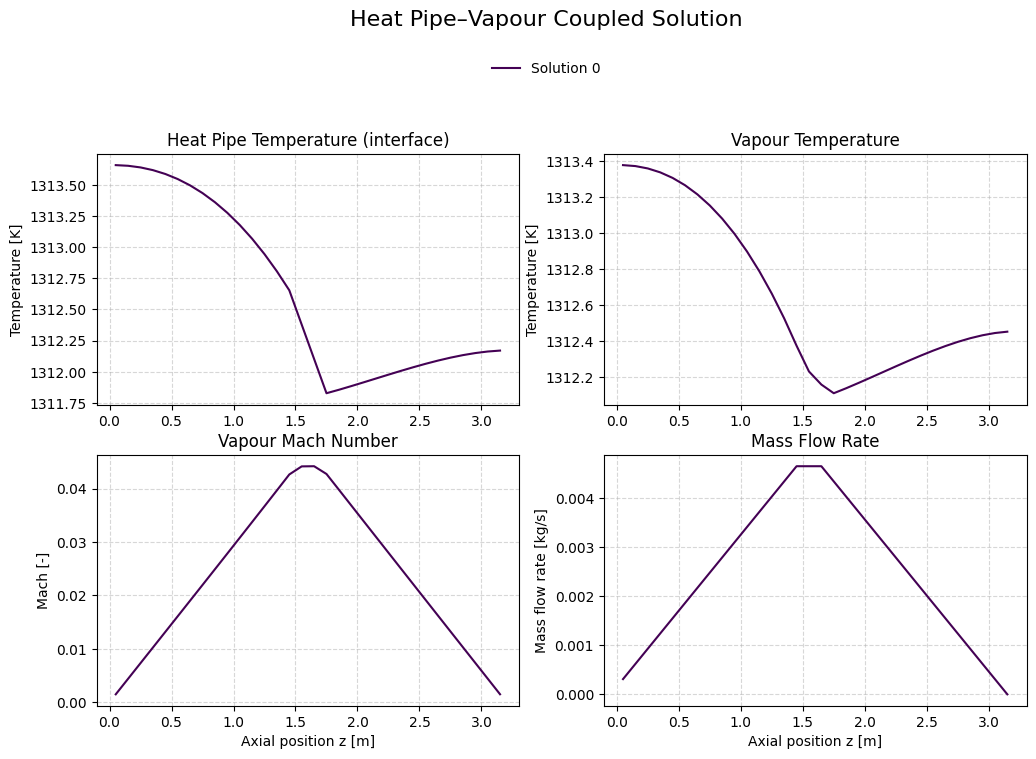

In [6]:
plot_heatpipe_solutions(solver)

In [7]:
import numpy as np

data_points = [
    [1.17, 2, 2.85, 3.775, 1.28, 1.71, 2.22, 0.58],
    [6.6, 10.95, 15.4, 19.7, 7.425, 10.74, 14.88, 2.43],
    [100, 100, 100, 100, 100, 100, 100, 100],
    [0.6, 1, 1.4, 1.8, 0.6, 0.6, 0.6, 0.6],
    [0.008, 0.008, 0.008, 0.008, 0.009, 0.013, 0.018, 0.003]
]

data_points = np.array(data_points)

Q_lows  = data_points[0] * 1e3
Q_highs = data_points[1] * 1e3
hs      = data_points[2]
L_conds = data_points[3]
r_outs  = data_points[4]

In [8]:
delta_Ts_low  = Q_lows  / (hs * L_conds * r_outs) / (2 * np.pi)
delta_Ts_high = Q_highs / (hs * L_conds * r_outs) / (2 * np.pi)

print(delta_Ts_low)
print(delta_Ts_high)

[387.94017379 397.88735773 404.99248912 417.22910429 377.2561614
 348.91660601 327.15182747 512.83259441]
[2188.38046751 2178.43328357 2188.38046751 2177.32804091 2188.38046751
 2191.4411395  2192.80143816 2148.59173174]
